# ⚡ 使用 GitHub 模型的并发代理工作流 (Python)

## 📋 高级并行处理教程

本笔记本演示了使用 Microsoft 代理框架的**并发工作流模式**。您将学习如何构建高性能、并行处理的工作流，其中多个 AI 代理同时执行，显著提高吞吐量并实现复杂的多线程业务流程。

## 🎯 学习目标

### 🚀 **并发处理基础**
- **并行代理执行**：同时运行多个代理以获得最大效率
- **工作流编排**：协调并发操作的同时保持数据一致性
- **性能优化**：通过并行处理实现显著的速度提升
- **资源管理**：在并发操作中高效利用 AI 模型资源

### 🏗️ **高级并发模式**
- **分叉-合并处理**：将工作分配给多个代理并合并结果
- **流水线并行**：重叠执行阶段以实现连续吞吐量
- **负载均衡**：在可用代理资源之间均匀分配工作
- **同步点**：在关键工作流阶段协调并发代理

### 🏢 **企业级并发应用**
- **高容量文档处理**：同时处理多个文档
- **实时内容分析**：对传入数据流的并发分析
- **批处理优化**：为大规模操作最大化吞吐量
- **多模态分析**：并行处理不同类型的内容（文本、图像、数据）

## ⚙️ 先决条件和设置

### 📦 **所需依赖**

安装具有并发工作流功能的代理框架：

```bash
pip install agent-framework-core -U
```

### 🔑 **GitHub 模型配置**

**环境设置 (.env 文件)**：
```env
GITHUB_TOKEN=your_github_personal_access_token
GITHUB_ENDPOINT=https://models.inference.ai.azure.com
GITHUB_MODEL_ID=gpt-4o-mini
```

**并发处理考虑因素**：
- **速率限制**：监控 GitHub 模型 API 对并发请求的速率限制
- **资源使用**：考虑多个并发代理的内存和 CPU 使用情况
- **错误处理**：为并行操作实现强大的错误恢复机制

### 🏗️ **并发工作流架构**

```mermaid
graph TD
    A[工作流开始] --> B[并发执行]
    B --> C[代理池 1]
    B --> D[代理池 2]
    B --> E[代理池 3]
    C --> F[结果聚合]
    D --> F
    E --> F
    F --> G[最终输出]
    
    H[GitHub 模型 API] --> C
    H --> D
    H --> E
```

**主要优势**：
- **⚡ 性能**：通过并行执行实现显著的速度提升
- **📈 可扩展性**：处理增加的工作负载而不需要成比例增加时间
- **🔄 效率**：更好地利用可用的计算资源
- **🎯 吞吐量**：在相同时间内处理更多工作

## 🎨 **并发工作流设计模式**

### 🔍 **研究与分析流水线**
```
研究任务 → 并行研究代理 → 内容合成 → 质量审查
```

### 📊 **数据处理工作流**
```
输入数据 → 并发处理代理 → 结果聚合 → 最终报告
```

### 🎭 **内容创建流水线**
```
内容简介 → 并行内容生成器 → 审查与合并 → 最终内容
```

### 🔄 **多阶段处理**
```
输入 → 阶段 1（并发）→ 阶段 2（并发）→ 阶段 3（顺序）→ 输出
```

## 🏢 **企业级性能优势**

### ⚡ **吞吐量优化**
- **并行执行**：多个代理同时工作
- **资源利用**：可用 AI 模型容量的最大效率
- **时间减少**：总处理时间的显著减少
- **可扩展架构**：根据需要轻松添加更多并发代理

### 🛡️ **可靠性与弹性**
- **容错**：单个代理故障不会停止整个工作流
- **错误隔离**：一个并发分支中的问题不会影响其他分支
- **优雅降级**：即使代理容量减少，系统也能继续运行
- **恢复机制**：对失败操作的自动重试和错误处理

### 📊 **监控与可观察性**
- **并发执行跟踪**：监控所有并行操作的进度
- **性能指标**：测量速度提升和效率增益
- **资源使用分析**：优化并发代理分配
- **瓶颈识别**：发现并解决性能约束

让我们构建高性能的并发 AI 工作流！🚀

In [ ]:
! pip install agent-framework-core -U

In [1]:
import os
from typing import Any

from agent_framework import ChatMessage, ConcurrentBuilder,WorkflowViz
from agent_framework.openai import OpenAIChatClient

In [2]:
import dotenv
dotenv.load_dotenv()

chat_client = OpenAIChatClient(
    base_url=os.getenv("API_URL"),
    api_key=os.getenv("API_KEY"),
    model_id=os.getenv("MODEL_FREE_8B")
)


In [3]:
ResearcherAgentName = "Researcher-Agent"
ResearcherAgentInstructions = "You are my travel researcher, working with me to analyze the destination, list relevant attractions, and make detailed plans for each attraction."

In [4]:
PlanAgentName = "Plan-Agent"
PlanAgentInstructions = "You are my travel planner, working with me to create a detailed travel plan based on the researcher's findings."

In [5]:
research_agent   = chat_client.as_agent(
        instructions=(
           ResearcherAgentInstructions
        ),
        name=ResearcherAgentName,
    )

plan_agent = chat_client.as_agent(
        instructions=(
            PlanAgentInstructions
        ),
        name=PlanAgentName,
    )

In [6]:
workflow = ConcurrentBuilder().participants([research_agent, plan_agent]).build()

In [7]:
print("生成工作流可视化...")
viz = WorkflowViz(workflow)
# 打印出 mermaid 字符串。
print("Mermaid 字符串: \n=======")
print(viz.to_mermaid())
print("=======")
# 打印出 DiGraph 字符串。
print("DiGraph 字符串: \n=======")
print(viz.to_digraph())
print("=======")
svg_file = viz.export(format="svg")
print(f"SVG 文件保存到: {svg_file}")

生成工作流可视化...
Mermaid 字符串: 
flowchart TD
  dispatcher["dispatcher (Start)"];
  Researcher_Agent["Researcher-Agent"];
  Plan_Agent["Plan-Agent"];
  aggregator["aggregator"];
  fan_in__aggregator__69d73de8((fan-in))
  Plan_Agent --> fan_in__aggregator__69d73de8;
  Researcher_Agent --> fan_in__aggregator__69d73de8;
  fan_in__aggregator__69d73de8 --> aggregator;
  dispatcher --> Researcher_Agent;
  dispatcher --> Plan_Agent;
DiGraph 字符串: 
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "dispatcher" [fillcolor=lightgreen, label="dispatcher\n(Start)"];
  "Researcher-Agent" [label="Researcher-Agent"];
  "Plan-Agent" [label="Plan-Agent"];
  "aggregator" [label="aggregator"];

  "fan_in::aggregator::69d73de8" [shape=ellipse, fillcolor=lightgoldenrod, label="fan-in"];
  "Plan-Agent" -> "fan_in::aggregator::69d73de8";
  "Researcher-Agent" -> "fan_in::aggregator::69d73de8";
  "fan_in::aggregator::69d73de8" -> "aggregator

尝试显示 SVG 文件，路径: /tmp/tmpkxbyo0y1.svg


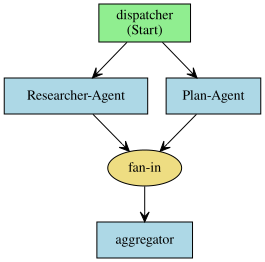

In [8]:
from IPython.display import SVG, display, HTML
import os

print(f"尝试显示 SVG 文件，路径: {svg_file}")

if svg_file and os.path.exists(svg_file):
    try:
        # 首选：直接 SVG 渲染
        display(SVG(filename=svg_file))
    except Exception as e:
        print(f"⚠️ 直接 SVG 渲染失败: {e}。回退到原始 HTML。")
        try:
            with open(svg_file, "r", encoding="utf-8") as f:
                svg_text = f.read()
            display(HTML(svg_text))
        except Exception as inner:
            print(f"❌ 回退 HTML 渲染也失败: {inner}")
else:
    print("❌ 未找到 SVG 文件。确保 viz.export(format='svg') 成功运行。")

In [9]:
events = await workflow.run("Plan a trip to Seattle in December")
outputs = events.get_outputs()

In [10]:
if outputs:
        print("===== 最终聚合对话 (messages) =====")
        for output in outputs:
            messages: list[ChatMessage] | Any = output
            for i, msg in enumerate(messages, start=1):
                name = msg.author_name if msg.author_name else "user"
                print(f"{'-' * 60}\n\n{i:02d} [{name}]:\n{msg.text}")

===== 最终聚合对话 (messages) =====
------------------------------------------------------------

01 [user]:
Plan a trip to Seattle in December
------------------------------------------------------------

02 [Researcher-Agent]:
Planning a trip to Seattle in December is a great idea! December is a popular time for visitors to experience the city's unique charm, including its mild winter weather, festive holiday atmosphere, and many indoor attractions. Below is a detailed travel plan to help you make the most of your December visit to Seattle, covering key attractions, local culture, and practical tips.

---

## 🗺️ Seattle in December: A Traveler's Guide

### 🌧️ Weather and Travel Tips:
- **Average temperature**: 43°F to 55°F (6°C to 13°C) with frequent rain and cloud cover.
- **Floors or sidewalks** can be slippery, so wear waterproof shoes and carry an umbrella or wear a rain jacket.
- **Warm clothing is advisable**, including scarves, hats, and layers.
- **December 25** is **Rainy Day** (n